# 06 — Advanced Features: Star Features + Strength of Schedule

**Diagnosis from NB_05:** team-aggregated box-score features only added ~0.6 pp accuracy ... basically nothing. 
**Reason:** they correlate too strongly with form & ELO, which we already have

**Hypothesis:** three concepts carry additional information that ELO/form cannot absorb:

1. **Star availability:** How many of the core players were actually in recent lineups? Injuries = change of team identity.
2. **Strength of schedule** A 8-game win streak against shit teams is not the same as against conference leaders.
3. **Quality wins** — record against top opponents, weighted by their ELO.


## 1. Setup

In [1]:
#packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
import xgboost as xgb

# plot style Latex <3
sys.path.insert(0, str(Path("..").resolve()))
from src.plot_style import apply
apply()

DATA_RAW = Path("..") / "data" / "raw"
DATA_PROCESSED = Path("..") / "data" / "processed"

games = pd.read_parquet(DATA_PROCESSED / "games_with_player_features.parquet")
print(f"Games: {len(games):,}  ({games.season.min()} - {games.season.max()})")

Games: 71,239  (1946 - 2025)


## 2. Star availability:

**Idea:** 
I dont have data that shows me wehter my top players are sick/ injured etc. To capture this somehow I identify per team and season the **top 5 players by minutes** up to the current game. Then I count how many of those were active in the last 3 games.

Few top-5 available = injury wave = likely worse performance.


In [2]:
# read data
ps = pd.read_csv(DATA_RAW / "PlayerStatistics.csv",
                 usecols=["gameId", "playerteamId", "personId", "numMinutes", "comment"],
                 low_memory=False)
# numMinutes has mixed types (older data stored as strings) -> clean numeric conversion
ps["numMinutes"] = pd.to_numeric(ps["numMinutes"], errors="coerce")
ps["played"] = (ps["numMinutes"].fillna(0) > 0).astype(int)

# attach game date + season
ps = ps.merge(games[["gameId", "gameDate", "season"]], on="gameId", how="inner")
print(f"Player-game rows: {len(ps):,}")

Player-game rows: 1,603,395


In [3]:
# top 5 players per team BEFORE the current game — no lookahead!
# the previous version of this cell aggregated minutes over the WHOLE season,
# which meant in November we already "knew" who the season's top-5 minute leaders would be.
# fix: cumulative minutes up to (but excluding) the current game.

ps = ps.sort_values(["season", "playerteamId", "personId", "gameDate"]).reset_index(drop=True)

# step 1: per (season, team, player) running sum of minutes BEFORE the current row
ps["cum_min_to_date"] = (
    ps.groupby(["season", "playerteamId", "personId"])["numMinutes"]
      .transform(lambda s: s.shift(1).fillna(0).cumsum())
)

# step 2: within each game-team, rank players by minutes-played-so-far this season
ps["rank"] = (
    ps.groupby(["gameId", "playerteamId"])["cum_min_to_date"]
      .rank(method="dense", ascending=False)
)
ps["is_top5"] = (ps["rank"] <= 5).astype(int)

print(f"Top-5 markers set: {ps.is_top5.sum():,}")
print("(Note: first ~5 games of each season the top-5 is still settling — that's expected, no way around it without leaking the future.)")

Top-5 markers set: 717,897
(Note: first ~5 games of each season the top-5 is still settling — that's expected, no way around it without leaking the future.)


In [4]:
# per team-game: how many of the top 5 actually played?
core_avail = (
    ps[ps.is_top5 == 1]
    .groupby(["gameId", "playerteamId"], as_index=False)
    .agg(top5_played=("played", "sum"))
)

core_avail = core_avail.merge(games[["gameId", "gameDate"]], on="gameId").sort_values(["playerteamId", "gameDate"])

# rolling mean of top-5 availability over the last 3 games 
core_avail["top5_avail_last3"] = (
    core_avail.groupby("playerteamId")["top5_played"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)

core_avail.head(3)

,gameId,playerteamId,top5_played,gameDate,top5_avail_last3
58964,24900018,1.610613e+09,0,1949-11-05 19:00:00,NaN
58976,24900056,1.610613e+09,0,1949-11-15 19:00:00,0.0
58982,24900067,1.610613e+09,0,1949-11-17 19:00:00,0.0


## 3. Strength of Schedule (SoS):

I have ELO for both teams in every game. From a team-game perspective: the opponent's ELO at game time = how hard the matchup was.  
Rolling mean of the **last 10 opponent ELOs** = SoS of the recent stretch.

**Form adjusted for SoS:** average point margin minus an adjustment term based on opponent strength relative to league average (~1500). A +5 margin against top teams is worth more than +5 against shit teams.


In [5]:
# game -> team-game view with opponent ELO
tg_home = games[["gameId", "gameDate", "season", "hometeamId", "awayteamId",
                 "home_elo_pre", "away_elo_pre", "homeScore", "awayScore"]].copy()


tg_home = tg_home.rename(columns={
    "hometeamId": "teamId", "awayteamId": "oppId",
    "home_elo_pre": "team_elo", "away_elo_pre": "opp_elo",
    "homeScore": "pts", "awayScore": "opp_pts",})

tg_away = games[["gameId", "gameDate", "season", "awayteamId", "hometeamId",
                 "away_elo_pre", "home_elo_pre", "awayScore", "homeScore"]].copy()


tg_away = tg_away.rename(columns={
    "awayteamId": "teamId", "hometeamId": "oppId",
    "away_elo_pre": "team_elo", "home_elo_pre": "opp_elo",
    "awayScore": "pts", "homeScore": "opp_pts",})


tg = pd.concat([tg_home, tg_away], ignore_index=True).sort_values(["teamId", "gameDate"]).reset_index(drop=True)

tg["margin"] = tg.pts - tg.opp_pts
tg["win"] = (tg.margin > 0).astype(int)
tg["quality_win"] = ((tg.win == 1) & (tg.opp_elo > 1500)).astype(int)

grp = tg.groupby(["teamId", "season"])

tg["sos_last10"] = grp["opp_elo"].transform(lambda s: s.shift(1).rolling(10, min_periods=3).mean())
tg["quality_win_rate_last10"] = grp["quality_win"].transform(lambda s: s.shift(1).rolling(10, min_periods=3).mean())
tg["sos_adj_margin_last10"] = grp.apply(lambda d: (d.margin - (1500 - d.opp_elo) / 25).shift(1).rolling(10, min_periods=3).mean(),include_groups=False,).reset_index(level=[0, 1], drop=True)



sos_features = tg[["gameId", "teamId", "sos_last10", "quality_win_rate_last10", "sos_adj_margin_last10"]]
sos_features.head(5)

,gameId,teamId,sos_last10,quality_win_rate_last10,sos_adj_margin_last10
0,24900018,1610612737,NaN,NaN,NaN
1,24900056,1610612737,NaN,NaN,NaN
2,24900067,1610612737,NaN,NaN,NaN
3,24900073,1610612737,1521.333333,0.0,-5.480
4,24900090,1610612737,1502.150000,0.0,-5.414


## 4. Merge all new features back to game level

In [6]:
# star availability
g = games.merge(
    core_avail[["gameId", "playerteamId", "top5_avail_last3"]]
        .rename(columns={"playerteamId": "hometeamId", "top5_avail_last3": "home_top5_avail_last3"}),
    on=["gameId", "hometeamId"], how="left")


g = g.merge(
    core_avail[["gameId", "playerteamId", "top5_avail_last3"]]
        .rename(columns={"playerteamId": "awayteamId", "top5_avail_last3": "away_top5_avail_last3"}),
    on=["gameId", "awayteamId"], how="left")


g["top5_avail_diff"] = g.home_top5_avail_last3 - g.away_top5_avail_last3

# SoS
sos_cols = ["sos_last10", "quality_win_rate_last10", "sos_adj_margin_last10"]
g = g.merge(
    sos_features.rename(columns={c: f"home_{c}" for c in sos_cols} | {"teamId": "hometeamId"}),
    on=["gameId", "hometeamId"], how="left")


g = g.merge(
    sos_features.rename(columns={c: f"away_{c}" for c in sos_cols} | {"teamId": "awayteamId"}),
    on=["gameId", "awayteamId"], how="left")

for c in sos_cols:
    g[f"{c}_diff"] = g[f"home_{c}"] - g[f"away_{c}"]


g.to_parquet(DATA_PROCESSED / "games_with_advanced_features.parquet", index=False)
print(f"Total columns: {g.shape[1]}")

Total columns: 75


## 5. Sanity check

Quick test before feeding the model.

**First plot:** I split games into 10 buckets based on `top5_avail_diff` (how many home stars played recently minus how many away stars played). Then I count how often home won in each bucket. If star availability matters, the line should rise from left to right.

**Second plot:** same idea but with `sos_adj_margin_diff`. The home teams margin adjusted for how strong their opponents were minus the same for the away team. If "good results against strong opponents" carries signal, this line should also rise.


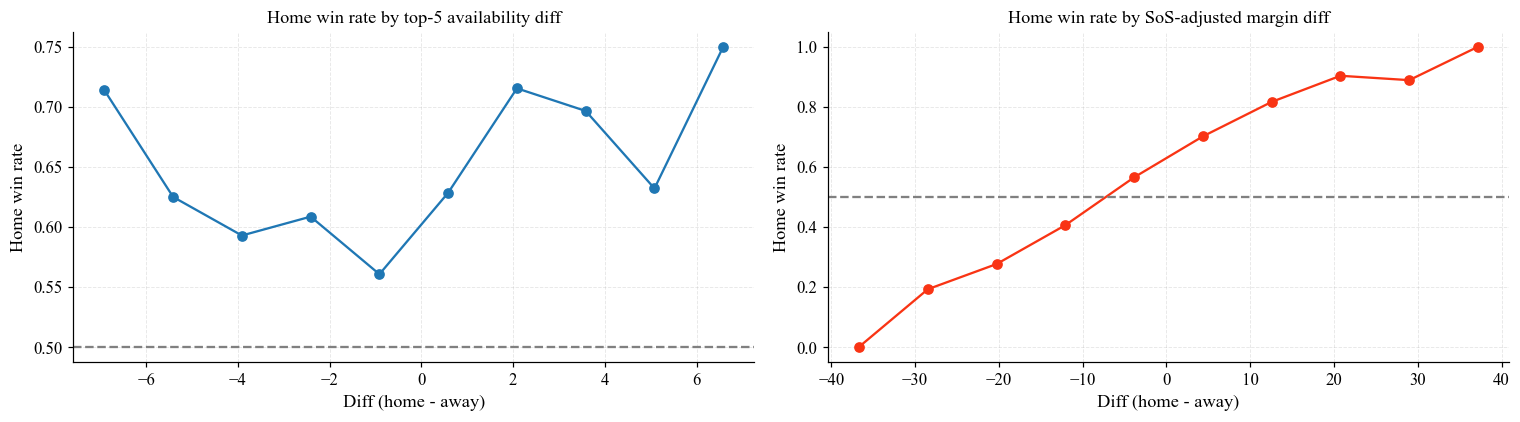

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: top-5 availability diff
tmp = g.dropna(subset=["top5_avail_diff", "home_win"]).copy()
tmp["bin"] = pd.cut(tmp.top5_avail_diff, bins=10)

binned = tmp.groupby("bin", observed=True).home_win.mean().reset_index()
binned["mid"] = binned["bin"].apply(lambda x: x.mid)



axes[0].plot(binned["mid"], binned["home_win"], marker="o", color="#1f77b4")
axes[0].axhline(0.5, color="gray", linestyle="--")
axes[0].set_title("Home win rate by top-5 availability diff")
axes[0].set_xlabel("Diff (home - away)")
axes[0].set_ylabel("Home win rate")

# right: SoS-adjusted margin diff
tmp = g.dropna(subset=["sos_adj_margin_last10_diff", "home_win"]).copy()
tmp["bin"] = pd.cut(tmp.sos_adj_margin_last10_diff, bins=10)

binned = tmp.groupby("bin", observed=True).home_win.mean().reset_index()
binned["mid"] = binned["bin"].apply(lambda x: x.mid)


axes[1].plot(binned["mid"], binned["home_win"], marker="o", color="#f93414")
axes[1].axhline(0.5, color="gray", linestyle="--")
axes[1].set_title("Home win rate by SoS-adjusted margin diff")
axes[1].set_xlabel("Diff (home - away)")
axes[1].set_ylabel("Home win rate")

plt.tight_layout()
plt.show()

**Result:** both lines going up. Flat = no signal. Up = the feature actually carries information about who wins

## 6. Model comparison: all feature sets

Three configurations:
1. **Basis** — ELO + form + h2h + rest (NB_03)
2. **+ Player box-score** (NB_05)
3. **+ Star availability + SoS** (this notebook)

In [8]:
BASIS = [
    'home_elo_pre', 'away_elo_pre', 'elo_diff',
    'h2h_home_winrate_last5',
    'home_win_rate_last_5', 'home_win_rate_last_10', 'home_win_rate_last_20',
    'away_win_rate_last_5', 'away_win_rate_last_10', 'away_win_rate_last_20',
    'win_rate_diff_5', 'win_rate_diff_10', 'win_rate_diff_20',
    'home_avg_margin_last_5', 'home_avg_margin_last_10', 'home_avg_margin_last_20',
    'away_avg_margin_last_5', 'away_avg_margin_last_10', 'away_avg_margin_last_20',
    'margin_diff_5', 'margin_diff_10', 'margin_diff_20',
    'home_days_since_last_game', 'away_days_since_last_game',
    'home_is_back_to_back', 'away_is_back_to_back', 'rest_diff',

]


PLAYER_BOX = [c for c in g.columns if any(c.endswith(s)
    for s in ['_roll10', '_roll10_diff'])]


ADVANCED = [
    'home_top5_avail_last3', 'away_top5_avail_last3', 'top5_avail_diff',
    'home_sos_last10', 'away_sos_last10', 'sos_last10_diff',
    'home_quality_win_rate_last10', 'away_quality_win_rate_last10', 'quality_win_rate_last10_diff',
    'home_sos_adj_margin_last10', 'away_sos_adj_margin_last10', 'sos_adj_margin_last10_diff',]


print('Basis:', len(BASIS), '| Player-Box:', len(PLAYER_BOX), '| Advanced:', len(ADVANCED))

Basis: 27 | Player-Box: 24 | Advanced: 12


In [9]:
def evaluate(features, name, df_):
    df_ = df_.dropna(subset=features + ["home_win"]).copy()
    train = df_[df_.season < 2019]
    test = df_[df_.season >= 2019]
    model = xgb.XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0,)

    
    model.fit(train[features], train["home_win"])
    proba = model.predict_proba(test[features])[:, 1]
    pred = (proba >= 0.5).astype(int)
    return model, {
        "name": name, "n_features": len(features), "n_train": len(train), "n_test": len(test),
        "accuracy": accuracy_score(test["home_win"], pred),
        "log_loss": log_loss(test["home_win"], proba),
        "brier":    brier_score_loss(test["home_win"], proba),
        "auc":      roc_auc_score(test["home_win"], proba),}

    

_, r1 = evaluate(BASIS, "Basis (ELO + form)", g)
_, r2 = evaluate(BASIS + PLAYER_BOX, "+ Player box-score", g)


model_full, r3 = evaluate(BASIS + PLAYER_BOX + ADVANCED, "+ Star avail + SoS (FULL)", g)


comp = pd.DataFrame([r1, r2, r3]).set_index("name").round(4)
comp

,n_features,n_train,n_test,accuracy,log_loss,brier,auc
name,,,,,,,
Basis (ELO + form),27,61623,8642,0.6412,0.6407,0.2238,0.6976
+ Player box-score,51,59434,7145,0.6484,0.6359,0.2216,0.6980
+ Star avail + SoS (FULL),63,59434,7145,0.6502,0.6345,0.2208,0.7006


## 7. Feature importance / strength?

In [10]:
all_feats = BASIS + PLAYER_BOX + ADVANCED
imp = pd.DataFrame({
    "feature": all_feats,
    "importance": model_full.feature_importances_,
    "group": ["Basis"]*len(BASIS) + ["Player-Box"]*len(PLAYER_BOX) + ["Advanced"]*len(ADVANCED),
}).sort_values("importance", ascending=False)


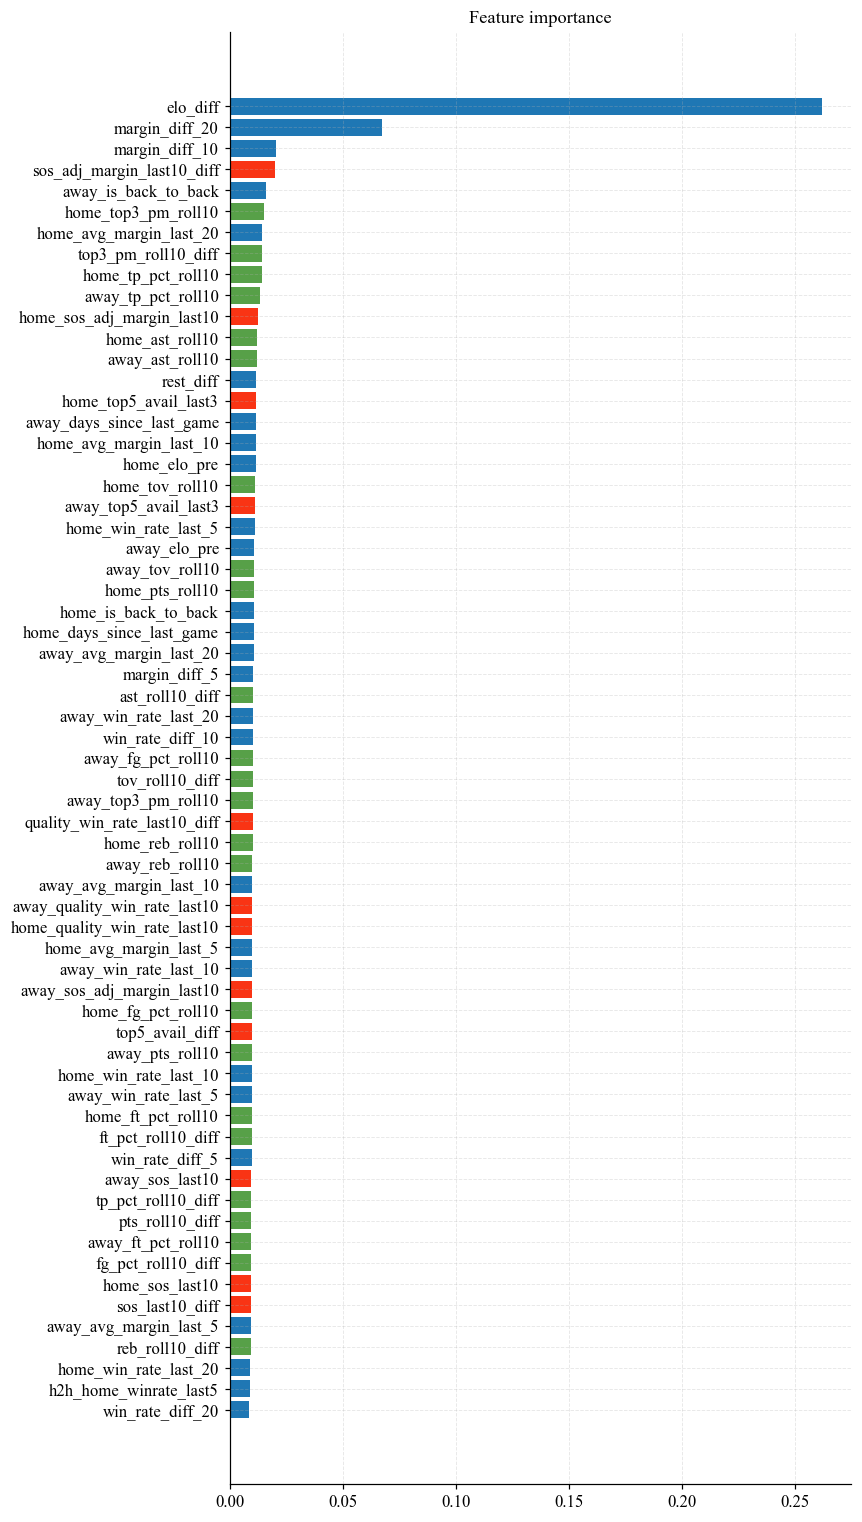


Mean importance per feature group:
group
Advanced      0.0111
Basis         0.0224
Player-Box    0.0109
Name: importance, dtype: float32


In [11]:
fig, ax = plt.subplots(figsize=(8, 14))
color_map = {"Basis": "#1f77b4", "Player-Box": "#57A048", "Advanced": "#f93414"}
colors = [color_map[grp] for grp in imp.group]
ax.barh(imp.feature, imp.importance, color=colors)
ax.set_title("Feature importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nMean importance per feature group:")
print(imp.groupby("group").importance.mean().round(4))

## Result:

- honestly the accuracy gain is small :/ 

- basis already gets ~64% vs. full model ~65%. So adding 36 features (player box + advanced) only buys me ~0.8 pp accuracy

- **BUT:** log-loss, Brier and AUC  keep improving across all three steps

- the FULL model is best on every probability metric

**Same caveat as NB_05:** these comparisons are on a single 2019 split, not walk-forward. So the 0.8 pp accuracy gap is within noise. The log-loss/Brier/AUC improvements are smaller but more consistent and probably real. If you want a clean accuracy comparison under walk-forward you'd have to rerun the loop from NB_04 three times with each feature set — I didnt have the patience.

**Summary:** team level data hits a ceiling around 65% accuracy. Star availability and SoS confirm there is signal beyond ELO/form, but to break through I would probably need more data such as real time injury data and lineup level features.